In [2]:
import pandas as pd
from pathlib import Path
import numpy as np
import os
import json

In [2]:
embedding_path = "/home/kumargirish/data/prerequisites/ptbxl_text_embed.csv"
target_embedding_path = "/home/kumargirish/data/prerequisites/ptbxl_text_embed_with_reduced.csv"

### Load data

In [3]:
df = pd.read_csv(embedding_path)

In [4]:
df[["scp_codes", "text_embed"]].head()

,scp_codes,text_embed
0,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}","[-0.022633040323853493, -0.006966049782931805,..."
1,"{'NORM': 80.0, 'SBRAD': 0.0}","[-0.0300989281386137, -0.012552031315863132, 0..."
2,"{'NORM': 100.0, 'SR': 0.0}","[-0.012751703150570393, -0.012646425515413284,..."
3,"{'NORM': 100.0, 'SR': 0.0}","[-0.012751703150570393, -0.012646425515413284,..."
4,"{'NORM': 100.0, 'SR': 0.0}","[-0.012751703150570393, -0.012646425515413284,..."


### Convert to 15 labels

In [5]:
from label_utils import relabel_ndarray_of_71_label_arr_to_15_label_one_hot_arr, LABEL_15_NAMES

In [6]:
labels_arr = df["scp_codes"].apply(
    lambda x: json.loads(x.replace("'", '"')).keys()
)
labels_arr.shape

(21797,)

In [7]:
d_15_labels = relabel_ndarray_of_71_label_arr_to_15_label_one_hot_arr(labels_arr)
d_15_labels.shape

(21797, 15)

### Reduce embeddings

In [8]:
encodings = np.vstack(
    [np.array(x.strip("[]").split(",")).astype(float) for x in df["text_embed"]]
)
encodings.shape

(21797, 1536)

In [9]:
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from sklearn.preprocessing import MinMaxScaler

/home/kumargirish/miniconda3/envs/MGB-MAIDAP/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
reducer_type = "umap"

#### 2d

In [11]:
if reducer_type == "tsne":
    reducer = TSNE(n_components=2)
elif reducer_type == "umap":
    reducer = umap.UMAP(n_components=2)

In [12]:
embeddings_2d = reducer.fit_transform(encodings)

/home/kumargirish/miniconda3/envs/MGB-MAIDAP/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [13]:
embeddings_2d = MinMaxScaler().fit_transform(embeddings_2d)

In [14]:
embeddings_2d.shape

(21797, 2)

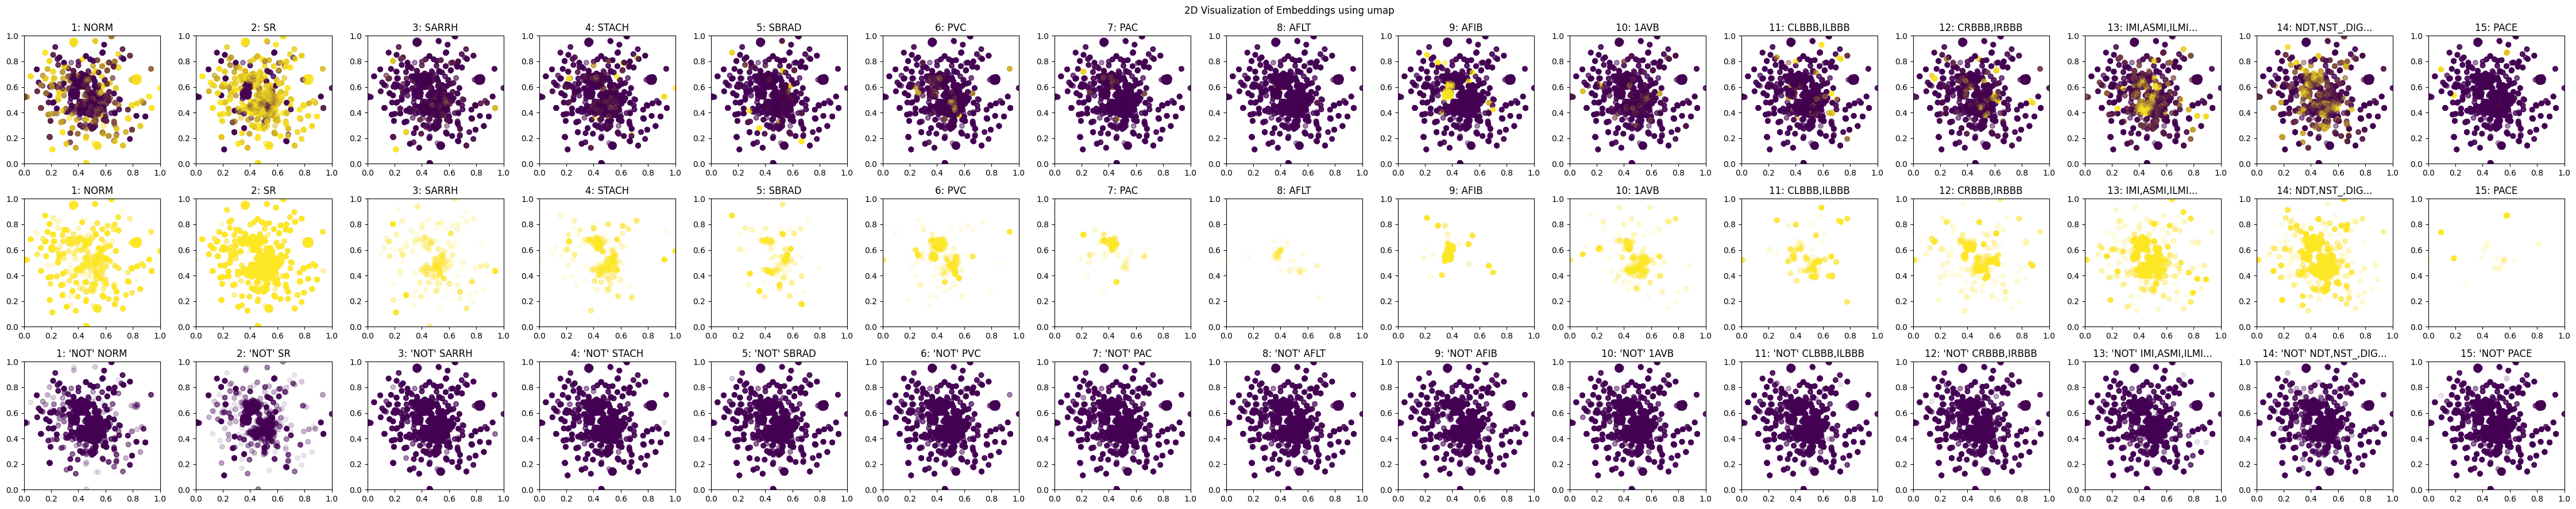

In [15]:
# Visualize the embeddings
fig, ax = plt.subplots(3, 15, figsize=(45, 9))
viridis = mpl.colormaps['viridis'].resampled(2)

for label_idx, label_name_iter in enumerate(LABEL_15_NAMES):

    # Both together
    ax_to_plot = ax[0, label_idx]
    title_for_label = f"{label_idx + 1}: {label_name_iter}"
    ax_to_plot.scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        label=title_for_label,
        alpha=0.1,
        c=viridis((d_15_labels[:, label_idx] == 1)),
    )
    ax_to_plot.set_title(title_for_label)
    ax_to_plot.set_xlim(0, 1)
    ax_to_plot.set_ylim(0, 1)

    # Positive for label
    ax_to_plot = ax[1, label_idx]
    d_indices = d_15_labels[:, label_idx] == 1
    title_for_label = f"{label_idx + 1}: {label_name_iter}"
    ax_to_plot.scatter(
        embeddings_2d[d_indices, 0],
        embeddings_2d[d_indices, 1],
        label=title_for_label,
        alpha=0.1,
        c=viridis(np.ones(d_indices.sum())),
    )
    ax_to_plot.set_title(title_for_label)
    ax_to_plot.set_xlim(0, 1)
    ax_to_plot.set_ylim(0, 1)

    # Negative for label
    ax_to_plot = ax[2, label_idx]
    d_indices = d_15_labels[:, label_idx] == 0
    title_for_label = f"{label_idx + 1}: \'NOT\' {label_name_iter}"
    ax_to_plot.scatter(
        embeddings_2d[d_indices, 0],
        embeddings_2d[d_indices, 1],
        label=title_for_label,
        alpha=0.1,
        c=viridis(np.zeros(d_indices.sum())),
    )
    ax_to_plot.set_title(title_for_label)
    ax_to_plot.set_xlim(0, 1)
    ax_to_plot.set_ylim(0, 1)

plt.suptitle(f"2D Visualization of Embeddings using {reducer_type}")
# plt.figlegend(loc="outside lower center", ncols=5)
plt.tight_layout()
plt.show()

#### 3d

In [16]:
if reducer_type == "tsne":
    reducer = TSNE(n_components=3)
elif reducer_type == "umap":
    reducer = umap.UMAP(n_components=3)

In [17]:
embeddings_3d = reducer.fit_transform(encodings)

/home/kumargirish/miniconda3/envs/MGB-MAIDAP/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [18]:
embeddings_3d = MinMaxScaler().fit_transform(embeddings_3d)

In [19]:
embeddings_3d.shape

(21797, 3)

### Saving reduced embeddings

In [20]:
df.loc[:, "text_embed_2d"] = [str(x) for x in embeddings_2d.tolist()]

In [21]:
df.loc[:, "text_embed_3d"] = [str(x) for x in embeddings_3d.tolist()]

In [22]:
df[["text_embed", "text_embed_2d", "text_embed_3d"]].head()

,text_embed,text_embed_2d,text_embed_3d
0,"[-0.022633040323853493, -0.006966049782931805,...","[0.6926275491714478, 0.8565853238105774]","[0.34381037950515747, 0.45445913076400757, 0.2..."
1,"[-0.0300989281386137, -0.012552031315863132, 0...","[0.5861125588417053, 0.6087801456451416]","[0.3266755938529968, 0.44739657640457153, 0.35..."
2,"[-0.012751703150570393, -0.012646425515413284,...","[0.8280683755874634, 0.6507617235183716]","[0.4752125144004822, 0.2293664664030075, 0.017..."
3,"[-0.012751703150570393, -0.012646425515413284,...","[0.8133090734481812, 0.6466912031173706]","[0.4749308228492737, 0.20686736702919006, 0.03..."
4,"[-0.012751703150570393, -0.012646425515413284,...","[0.8359721302986145, 0.6620410680770874]","[0.4665929079055786, 0.21249188482761383, 0.03..."


In [23]:
df['text_embed'].iloc[0]

'[-0.022633040323853493, -0.006966049782931805, 0.0043206727132201195, -0.0008471663459204137, -0.031201547011733055, 0.009985554032027721, -0.01485914085060358, -0.017825670540332794, -0.0105748875066638, 0.005108657293021679, 0.00776065606623888, 0.04934506118297577, -0.012786542065441608, -0.0071647013537585735, -0.010058392770588398, -0.014422106556594372, 0.015587530098855495, 0.005323863122612238, 0.011813148856163025, 0.004582230467349291, 0.0067276679910719395, 0.030459914356470108, -0.009277029894292355, 0.004853721242398024, 0.0009171082638204098, 0.003973032347857952, 0.005582110490649939, -0.01614375412464142, 0.004118710290640593, 0.012329643592238426, 0.0026288230437785387, -0.0179316196590662, -0.016739709302783012, -0.008462558500468731, -0.014422106556594372, -0.01470021903514862, 0.0010023629292845726, 0.005939682945609093, 0.023705758154392242, 0.005588732194155455, 0.02452685311436653, -0.008727427572011948, -0.0008223348995670676, 0.016448352485895157, -0.015918616

In [24]:
df['text_embed_2d'].iloc[0]

'[0.6926275491714478, 0.8565853238105774]'

In [25]:
df.to_csv(target_embedding_path, index=False)